In [1]:
from dateutil.parser import parse 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split


from scipy.stats import norm
import statsmodels.api as sm
from datetime import datetime

from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) 



In [2]:
# dataset source:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv', parse_dates=['date'], index_col='date')
df.head()

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


In [ ]:
################################
################################
#1. Visualizando a série temporal

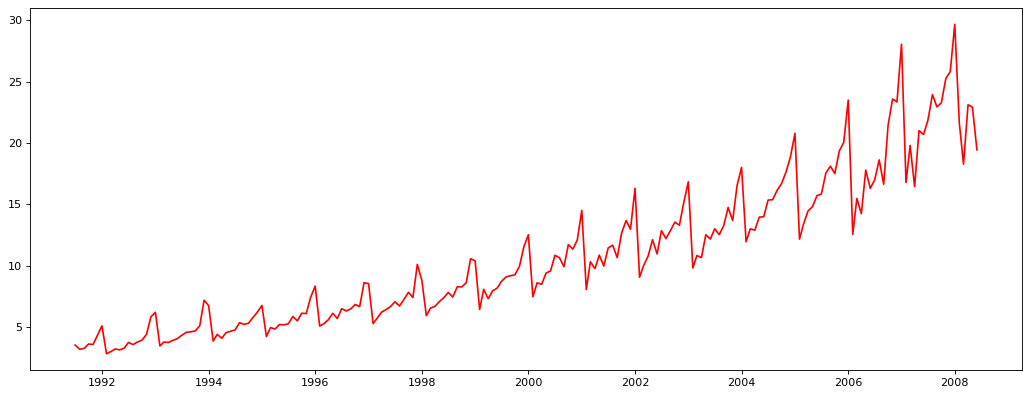

In [3]:
fig  = plt.subplots(1, figsize=(16,6), dpi= 80)
plt.plot(df, color='red')

In [4]:
################################
################################
#2. Verificando se a série é um Ruído Branco
#Usando Teste Ljung-Box

In [5]:
sm.stats.acorr_ljungbox(df, lags=[5], return_df=True)

,lb_stat,lb_pvalue
5,784.110251,3.167141e-167


p_valor < nível_significancia  => rejeitar a hipotese nula => série não é ruído branco

In [6]:
################################
################################
#3. Verificando se a série é Estacionária
# ADF test 
#ADF test, where the null hypothesis is the time series possesses a unit root and is non-stationary. 
#So, id the P-Value in ADH test is less than the significance level (0.05), you reject the null hypothesis.
result = adfuller(df.value, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
#for key, value in result[4].items():
#    print('Critial Values:')
#    print(f'   {key}, {value}')

ADF Statistic: 3.145185689306744
p-value: 1.0


p_valor > nível_significancia  => não rejeita a hipotese nula => série não é estacionaria

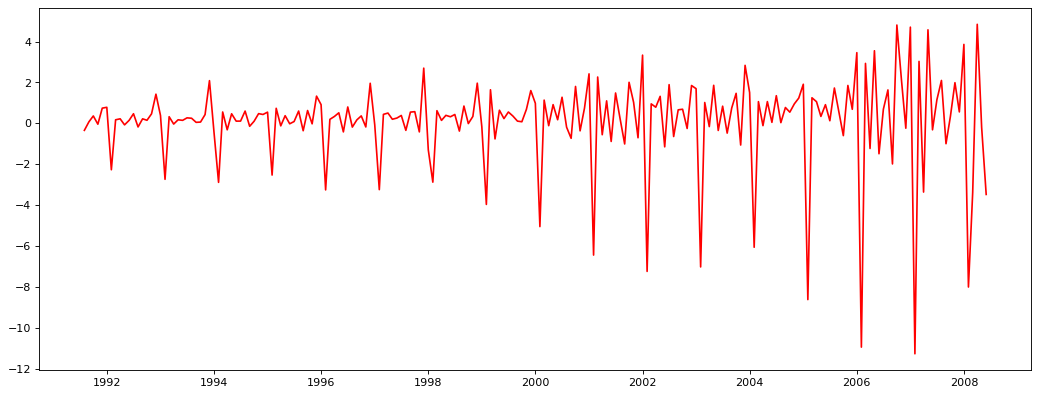

In [7]:
################################
################################
#4. Aplicando uma diferenciação para tornar a serie estacionáriaa
df_diff = df.value.diff()
fig  = plt.subplots(1, figsize=(16,6), dpi= 80)
plt.plot(df_diff, color='red')

A variabilidade da serie é muito diferente, para estabilizá-la vou aplicar o log antes de aplicar a primeira diferença

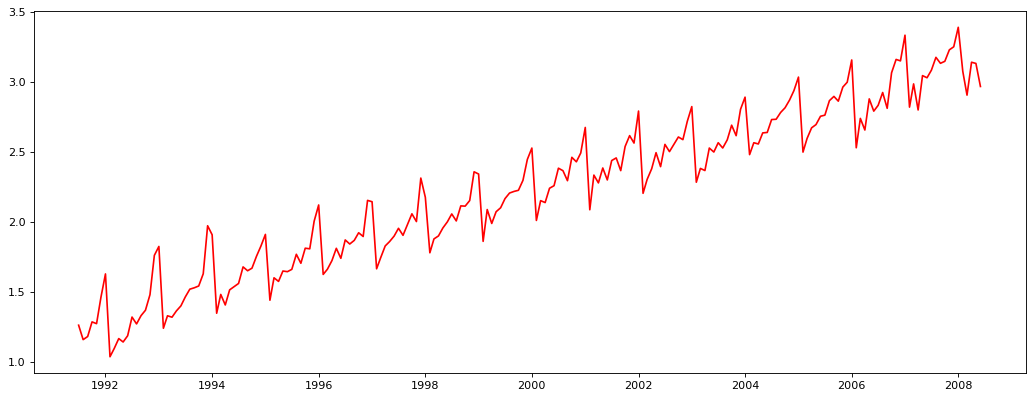

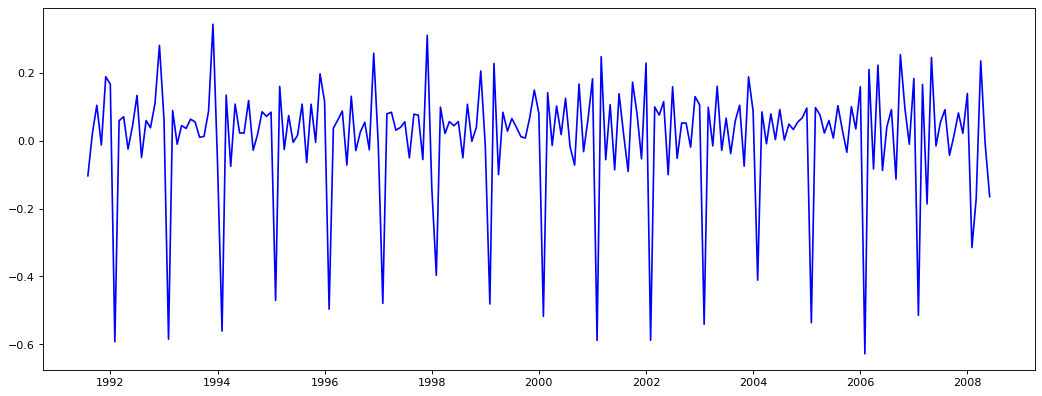

In [8]:
# aplicando o log
log_df = np.log(df['value'])

#aplicando a primeira diferença
diff_log_df = log_df.diff()


# plotando os dois graficos
fig  = plt.subplots(1, figsize=(16,6), dpi= 80)
plt.plot(log_df, color='red')
fig  = plt.subplots(1, figsize=(16,6), dpi= 80)
plt.plot(diff_log_df, color='blue')

In [ ]:
diff_log_df.head()

In [7]:
# verificar se a serie diferenciada é estacionária
teste = adfuller(diff_log_df.dropna(), autolag='AIC')
print(f'ADF Statistic: {teste[0]}')
print(f'p-value: {teste[1]}')

ADF Statistic: -4.519432426297142
p-value: 0.00018133843740899487


p_valor < nível_significancia =>  rejeita a hipotese nula => série  é estacionaria

In [ ]:
################################
################################
#5. IDENTIFICAÇÃO
# Verificando autocorrelação e autocorrelação parcial

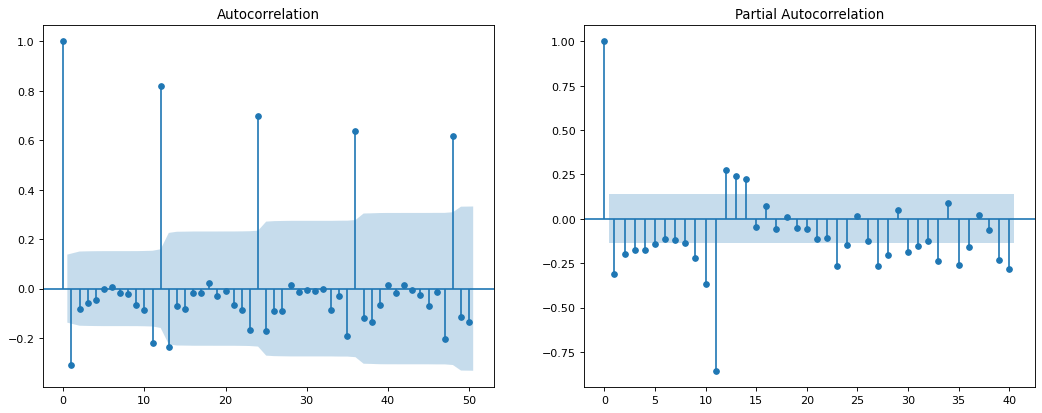

In [9]:
diff_log_df_1 = diff_log_df.dropna()
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16,6), dpi= 80)
fig=plot_acf(diff_log_df_1, ax=ax1, lags=50)
fig=plot_pacf(diff_log_df_1, ax=ax2, lags=40)

#SARIMA(p,d,q)(P,D,Q)s
# d=1
# D=1 s=12

Nota-se que há picos, 12, 24, 36, ..., que decaem lentamente pra dentro do intervalo de confiança, indicando a presença de sazonalidade de ordem 12. <br> Por esso mótivo vamos aplicar uma diferença sazonal de ordem 12 em cima de primeira diferença

In [13]:
diff12_diff_log_df = diff_log_df_1.diff(12)

In [14]:
diff12_diff_log_df = diff12_diff_log_df.dropna()

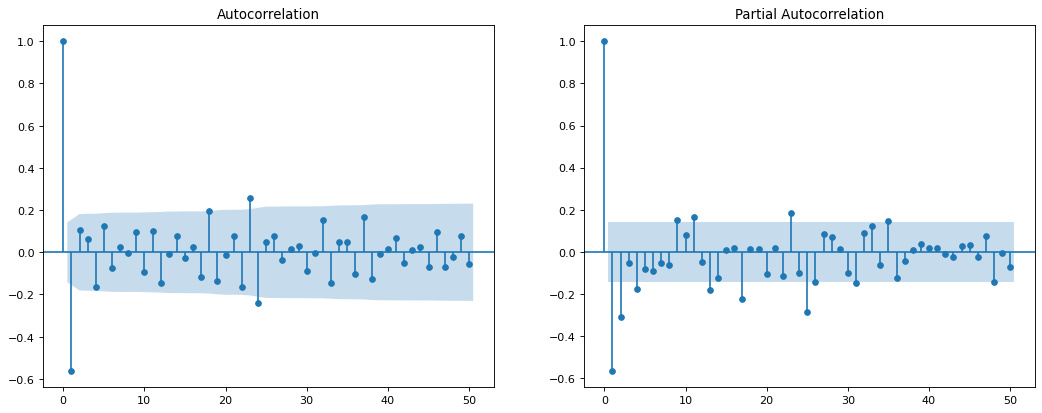

In [15]:
# Agora podemos plotar as funções acf e pacf novamente para enfim determinar o valor dos parametros, p, q, P e Q

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16,6), dpi= 80)
fig=plot_acf(diff12_diff_log_df, ax=ax1, lags=50)
fig=plot_pacf(diff12_diff_log_df, ax=ax2, lags=50)

# d=1
# D=1
# s=12

# p= até 5 (2)
# q= 1
# P=0
# Q= até 2 (0)

# #SARIMA(p,d,q)(P,D,Q)s
# SARIMA(5,1,1)(0,1,2)12

Olhando para a PACF podemos determinar os valores de P e p <br>
P será definido pelo número de lags multiplas de 12 fora do intervalo de confiança <br>
P=0 e <br>
p será determinado pelo número de lag fora do intervalo de confiança entre os lags multiplo de 12 <br>
p<=3 <br>

O mesmo vale para Q e q, mas olhando para a ACF <br>
Dessa maneira <br>
Q=1 <br>
q<=1<br>

In [12]:
# SARIMA(5,1,1)(0,1,2)12

In [13]:
################################
################################
# 5. ESTIMAÇÃO
# Ajusta o modelo

In [20]:
model = sm.tsa.statespace.SARIMAX(log_df, order=(5,1,1), seasonal_order=(0,1,1,12)) #aic=-511.894
#model = sm.tsa.statespace.SARIMAX(log_df, order=(2,1,1), seasonal_order=(0,1,0,12)) #aic=-458.645
results_SARIMA = model.fit()  
# summary of fit model
print(results_SARIMA.summary())

C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'
C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'


                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                  204
Model:             SARIMAX(5, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 263.947
Date:                            Mon, 27 Nov 2023   AIC                           -511.894
Time:                                    21:21:02   BIC                           -485.875
Sample:                                07-01-1991   HQIC                          -501.355
                                     - 06-01-2008                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2172      0.190     -1.145      0.252      -0.589       0.155
ar.L2          0.0414      0.172   

In [21]:
y_true = df.values
y_pred = results_SARIMA.fittedvalues
r2   = r2_score(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print('R2:   %.3f' % r2)
print('MSE:  %.3f' % mse)
print('RMSE: %.3f' % rmse)
print('MAE:  %.3f' % mae)
print('MAPE: %.3f' % mape)

R2:   -1.864
MSE:  101.131
RMSE: 10.056
MAE:  8.484
MAPE: 0.716


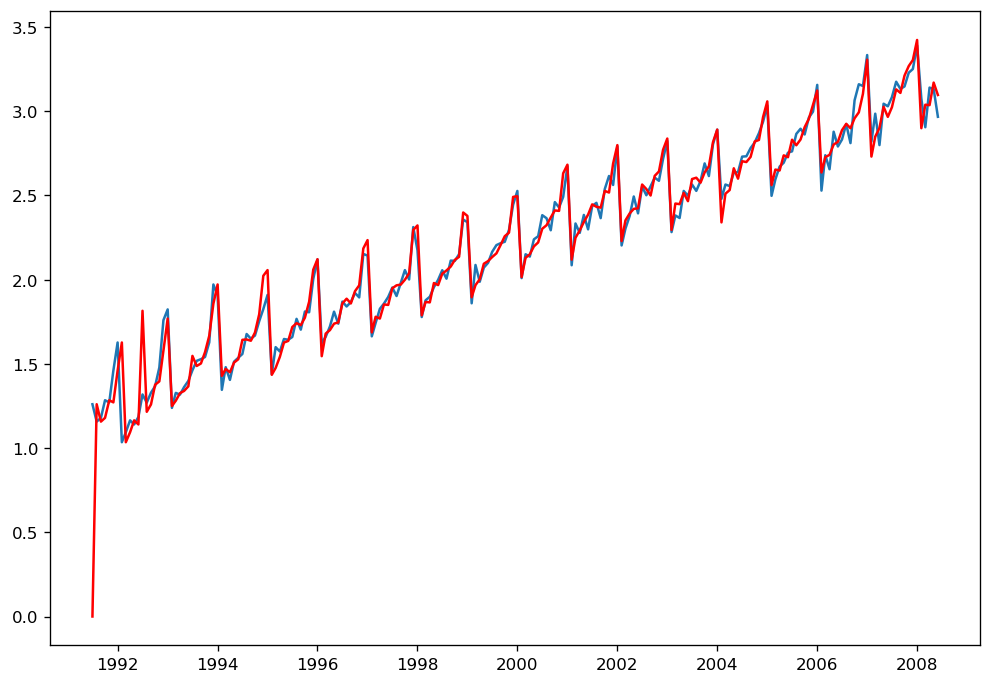

In [22]:
plt.plot(log_df)
plt.plot(results_SARIMA.fittedvalues, color='red')

In [17]:
################################
################################
# 6. VERIFICAÇÃO
# Avalia a qualidade do ajuste 

In [23]:
# Aplicando teste do ruido branco do resíduo
sm.stats.acorr_ljungbox(results_SARIMA.resid, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,29.363639,0.001088


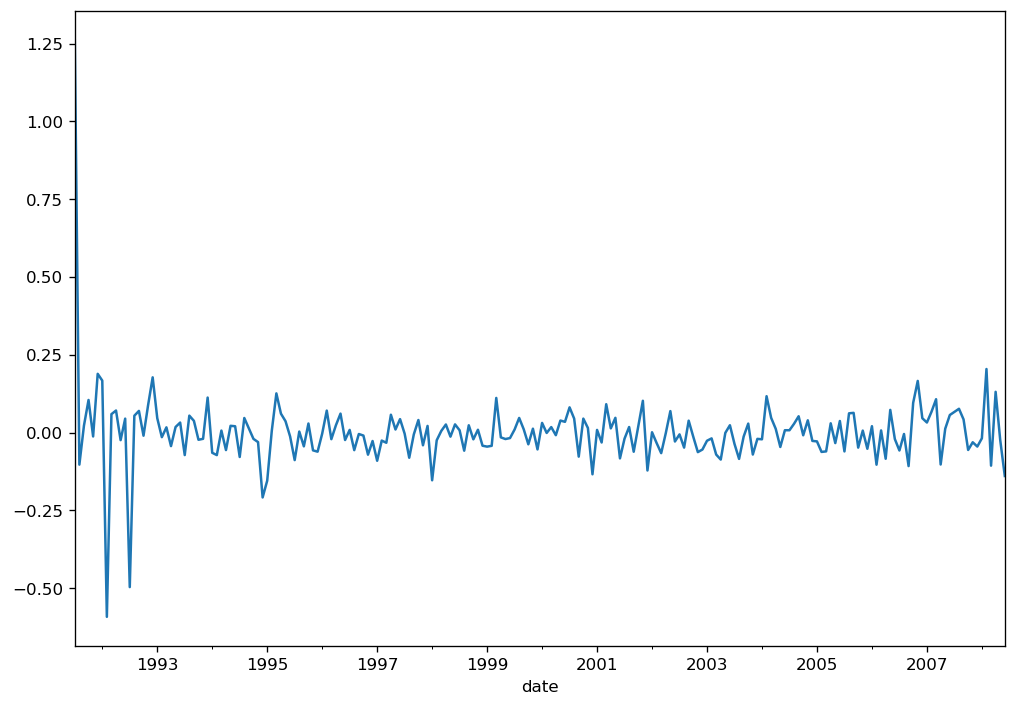

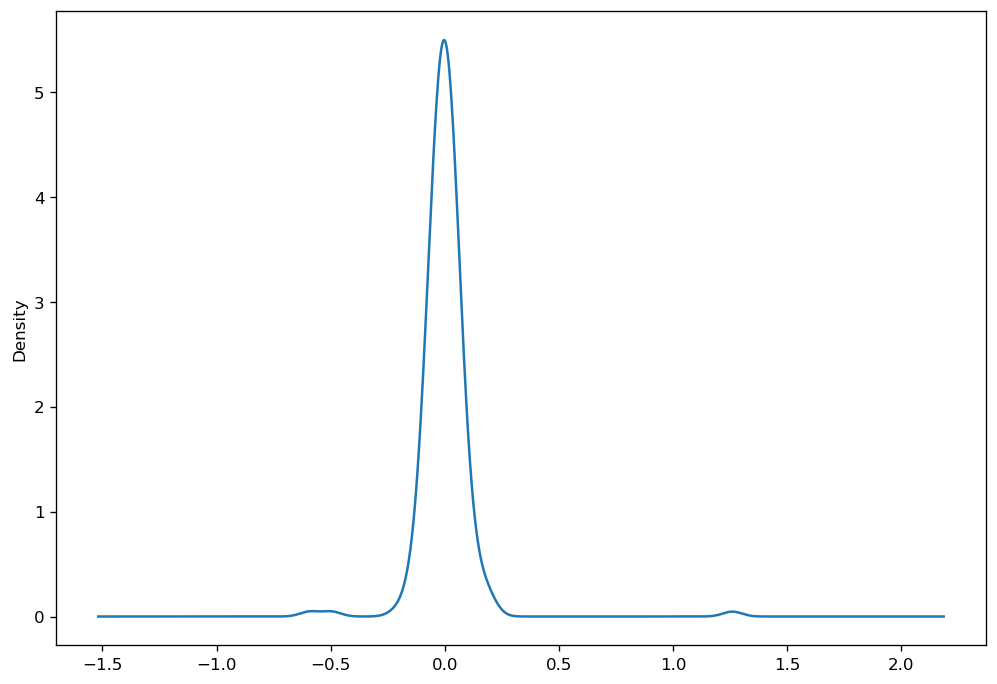

count    204.000000
mean       0.000215
std        0.121529
min       -0.592159
25%       -0.042913
50%       -0.002771
75%        0.037708
max        1.260332
dtype: float64


In [19]:
# Analisa também o residuo para verificar se satisfaz as condições de ruido branco
# line plot of residuals
residuals = results_SARIMA.resid
residuals.plot()
pyplot.show()
# density plot of residuals
residuals.plot(kind='kde')
pyplot.show()
# summary stats of residuals
print(residuals.describe())

In [24]:
################################
################################
# 6. PREVISÃO
predictions = np.exp(results_SARIMA.forecast(36))

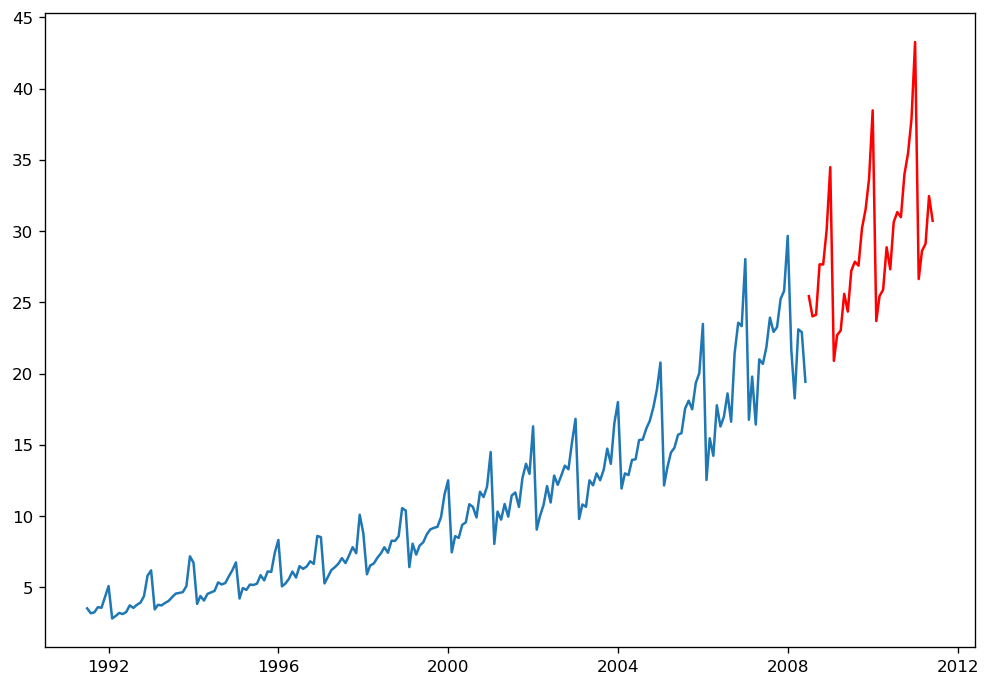

In [25]:
# plot forecasts against actual outcomes
pyplot.plot(df)
pyplot.plot(predictions, color='red')
pyplot.show()